# Customer Intelligence Analytics Platform
## Customer Segmentation

### Objective

Identify meaningful customer behavioral segments and unusual customer behavior
using unsupervised machine learning.

This notebook evaluates multiple clustering approaches rather than assuming a
single algorithm is optimal.

Models evaluated:

- K-Means
- Gaussian Mixture Models
- HDBSCAN

The final segmentation is selected using a combination of:

- Internal clustering metrics
- Cluster stability / size
- Behavioral separation
- Business interpretability

Isolation Forest is subsequently used to identify unusual customer behavior.

The final outputs will be consumed by Power BI.

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.ensemble import IsolationForest

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

In [149]:
df = pd.read_csv(
    "D:/clv/data/processed/customer_features.csv"
)

print("Shape:", df.shape)

Shape: (5881, 25)


In [150]:
required_columns = [
    "customer_id",
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days",
    "weekend_purchase_ratio",
    "return_order_rate",
    "return_item_rate",
    "R_score",
    "F_score",
    "M_score",
    "RFM_score",
    "rfm_segment"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

print("✓ Input validation successful")

✓ Input validation successful


### Feature Selection Rationale

The clustering feature set represents multiple dimensions of customer behavior:

| Dimension | Features |
|---|---|
| Engagement | Recency, Frequency |
| Monetary value | Monetary, Average Order Value |
| Basket behavior | Average Items per Order |
| Product breadth | Unique Products |
| Relationship duration | Active Months, Customer Lifetime |
| Purchase cadence | Average Purchase Interval |
| Return behavior | Return Order Rate, Return Item Rate |

RFM-derived labels and customer identifiers are excluded from the ML feature matrix.

In [151]:
ml_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days",
    "avg_purchase_interval_days",
    "return_order_rate",
    "return_item_rate"
]
X_raw = df[ml_features].copy()

X_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
recency,"5,881.000",201.458,209.474,1.000,26.000,96.000,380.000,739.000
frequency,"5,881.000",6.287,13.013,1.000,1.000,3.000,7.000,398.000
monetary,"5,881.000","2,954.396","14,437.323",0.000,341.900,865.600,"2,247.720","580,987.040"
avg_order_value,"5,881.000",384.976,"1,213.998",0.000,176.627,279.129,414.896,"84,236.250"
avg_items_per_order,"5,881.000",249.569,"1,433.120",1.000,90.952,153.500,257.000,"87,167.000"
unique_products,"5,881.000",81.950,116.475,1.000,19.000,45.000,103.000,"2,550.000"
active_months,"5,881.000",4.353,4.494,1.000,1.000,3.000,6.000,25.000
customer_lifetime_days,"5,881.000",272.883,258.815,0.000,0.000,220.000,511.000,738.000
avg_purchase_interval_days,"5,763.000",5.237,17.489,0.000,0.000,1.919,4.884,596.000
return_order_rate,"5,881.000",0.193,0.335,0.000,0.000,0.000,0.278,4.000


In [152]:
X_raw.isna().sum()

recency                         0
frequency                       0
monetary                        0
avg_order_value                 0
avg_items_per_order             0
unique_products                 0
active_months                   0
customer_lifetime_days          0
avg_purchase_interval_days    118
return_order_rate               0
return_item_rate                0
dtype: int64

In [153]:
imputer = SimpleImputer(
    strategy="median"
)

X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=ml_features,
    index=X_raw.index
)

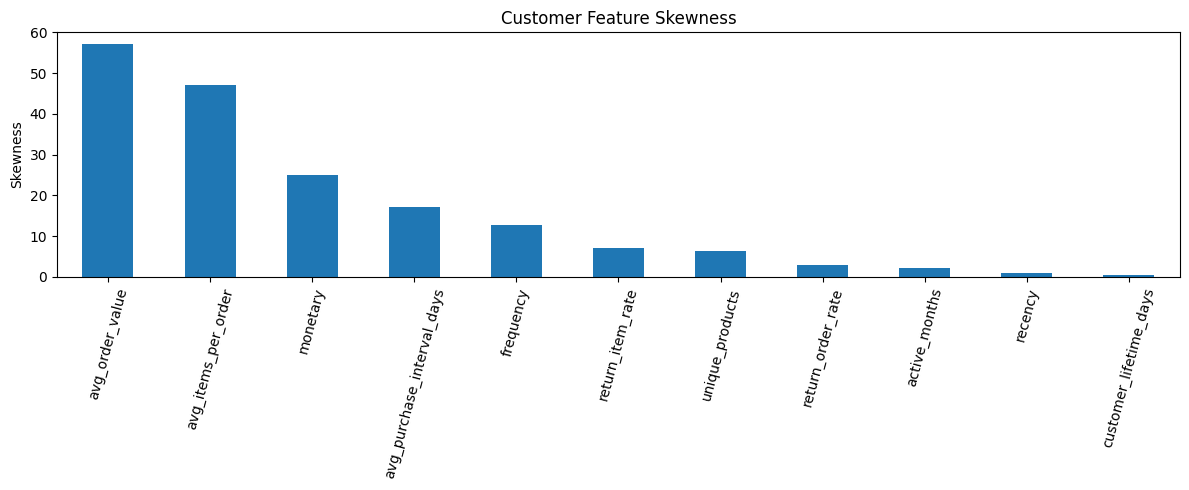

In [154]:
skewness = (
    X_imputed
    .skew()
    .sort_values(ascending=False)
)

skewness


plt.figure(figsize=(12, 5))

skewness.plot(kind="bar")

plt.title("Customer Feature Skewness")
plt.ylabel("Skewness")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [155]:
log_features = [
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days"
   
]
non_log_features = [
    "recency",
    "return_order_rate",
    "return_item_rate"
]
X_transformed = X_imputed.copy()

for col in log_features:
    X_transformed[col] = np.log1p(
        X_transformed[col]
    )
    
transformed_skewness = (
    X_transformed
    .skew()
    .sort_values(ascending=False)
)

skew_comparison = pd.DataFrame({
    "Before": X_imputed.skew(),
    "After": X_transformed.skew()
})

skew_comparison.sort_values(
    "Before",
    ascending=False
)

,Before,After
avg_order_value,57.144,-0.145
avg_items_per_order,47.125,-0.616
monetary,25.076,0.212
avg_purchase_interval_days,17.226,17.226
frequency,12.654,1.002
return_item_rate,6.955,6.955
unique_products,6.225,-0.284
return_order_rate,2.871,2.871
active_months,2.052,0.675
recency,0.887,0.887


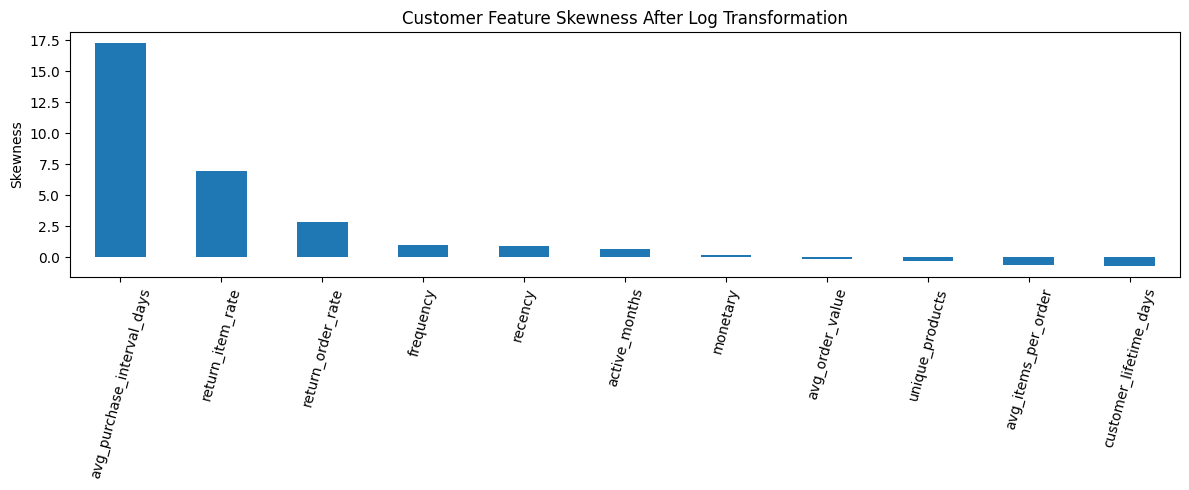

In [156]:
plt.figure(figsize=(12, 5))

transformed_skewness.plot(
    kind="bar"
)

plt.title("Customer Feature Skewness After Log Transformation")
plt.ylabel("Skewness")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [157]:
print("Return Order Rate")
print(X_imputed["return_order_rate"].describe())

print("\nReturn Item Rate")
print(X_imputed["return_item_rate"].describe())

print("\nPercentage of customers with zero return order rate:")
print(
    (X_imputed["return_order_rate"] == 0).mean() * 100
)

print("\nPercentage of customers with zero return item rate:")
print(
    (X_imputed["return_item_rate"] == 0).mean() * 100
)

Return Order Rate
count   5,881.000
mean        0.193
std         0.335
min         0.000
25%         0.000
50%         0.000
75%         0.278
max         4.000
Name: return_order_rate, dtype: float64

Return Item Rate
count   5,881.000
mean        0.016
std         0.061
min         0.000
25%         0.000
50%         0.000
75%         0.008
max         0.750
Name: return_item_rate, dtype: float64

Percentage of customers with zero return order rate:
57.303179731338204

Percentage of customers with zero return item rate:
57.303179731338204


In [158]:
X_transformed["has_return"] = (
    X_imputed["return_order_rate"] > 0
).astype(int)

X_transformed["has_return"].value_counts()

has_return
0    3370
1    2511
Name: count, dtype: int64

In [159]:
clustering_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days",
    "has_return"
]
X_model = X_transformed[
    clustering_features
].copy()
X_model.shape


(5881, 9)

In [160]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_model),
    columns=clustering_features,
    index=X_model.index
)
print("Shape:", X_scaled.shape)
print("Missing values:", X_scaled.isna().sum().sum())

Shape: (5881, 9)
Missing values: 0


In [161]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,"5,881.000",0.298,0.592,-0.268,-0.198,0.000,0.802,1.816
frequency,"5,881.000",0.117,0.584,-0.500,-0.500,0.000,0.500,3.320
monetary,"5,881.000",0.026,0.741,-3.597,-0.493,0.000,0.507,3.460
avg_order_value,"5,881.000",-0.025,0.878,-6.624,-0.535,0.000,0.465,6.707
avg_items_per_order,"5,881.000",-0.045,0.901,-4.214,-0.503,0.000,0.497,6.141
unique_products,"5,881.000",-0.043,0.740,-1.902,-0.505,0.000,0.495,2.436
active_months,"5,881.000",0.028,0.540,-0.553,-0.553,0.000,0.447,1.494
customer_lifetime_days,"5,881.000",-0.224,0.431,-0.865,-0.865,0.000,0.135,0.194
has_return,"5,881.000",0.427,0.495,0.000,0.000,0.000,1.000,1.000


PC1 variance: 0.5674536871520107
PC2 variance: 0.22433221965716574
Total explained variance: 0.7917859068091765


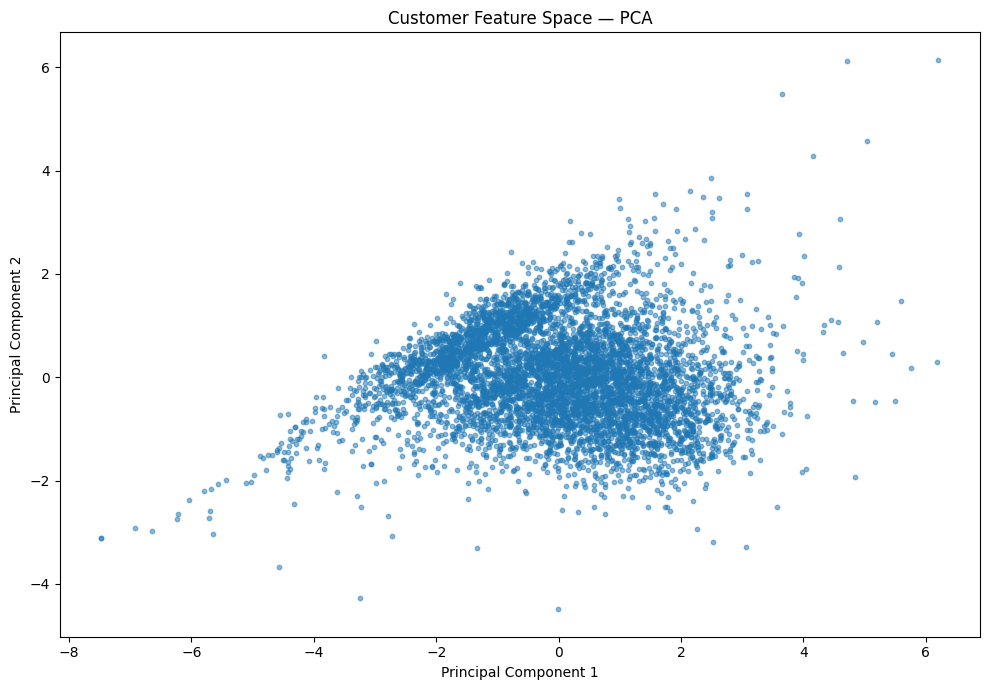

In [162]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print("PC1 variance:", pca.explained_variance_ratio_[0])
print("PC2 variance:", pca.explained_variance_ratio_[1])
print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10,
    alpha=0.5
)

plt.title("Customer Feature Space — PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

## K-Means 

In [163]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

k_values = range(2, 11)

kmeans_results = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    kmeans_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "davies_bouldin": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "calinski_harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        )
    })

kmeans_results = pd.DataFrame(kmeans_results)

kmeans_results

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,"15,513.559",0.306,1.224,"3,242.033"
1,3,"12,755.571",0.236,1.359,"2,606.635"
2,4,"11,014.376",0.225,1.332,"2,321.812"
3,5,"9,830.818",0.219,1.294,"2,127.534"
4,6,"9,142.810",0.194,1.352,"1,918.218"
5,7,"8,500.186",0.198,1.372,"1,793.082"
6,8,"7,960.920",0.191,1.363,"1,697.594"
7,9,"7,606.303",0.190,1.395,"1,588.598"
8,10,"7,289.581",0.189,1.417,"1,501.534"


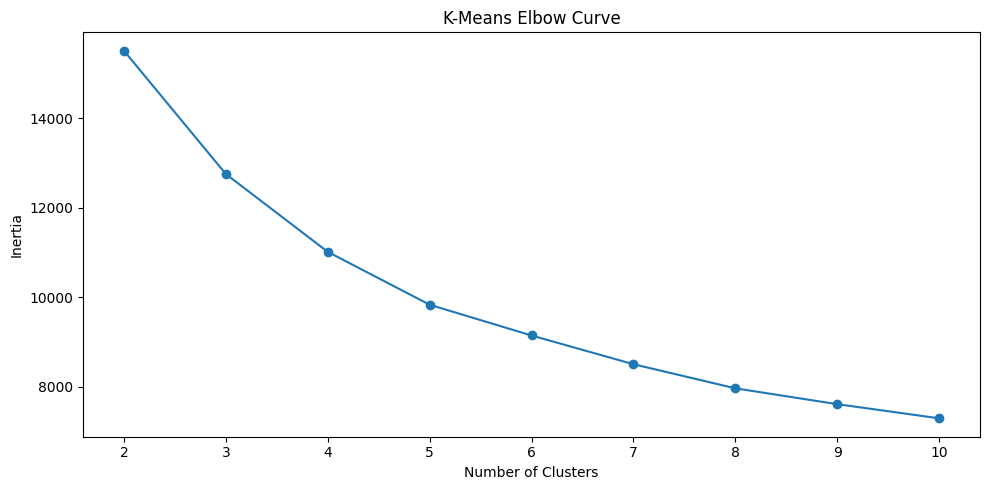

In [164]:
plt.figure(figsize=(10, 5))

plt.plot(
    kmeans_results["k"],
    kmeans_results["inertia"],
    marker="o"
)

plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)

plt.tight_layout()
plt.show()

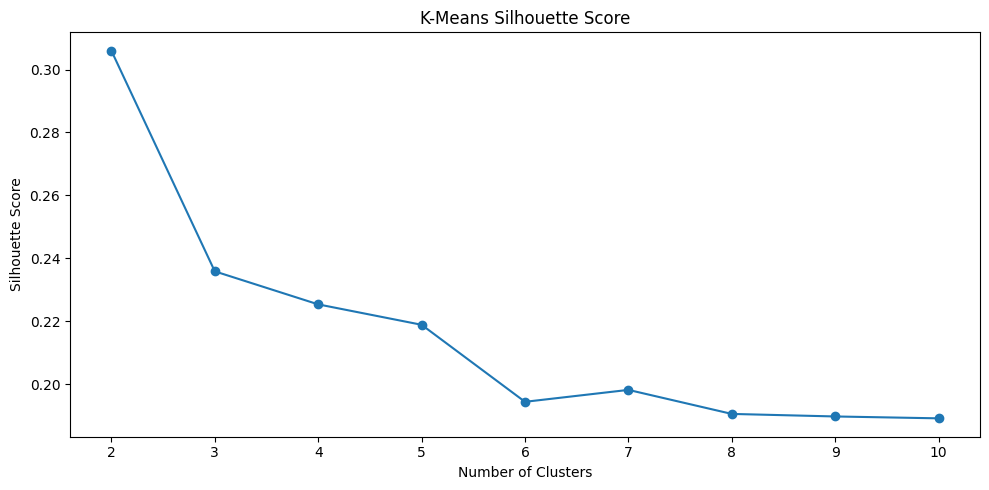

In [165]:
plt.figure(figsize=(10, 5))

plt.plot(
    kmeans_results["k"],
    kmeans_results["silhouette"],
    marker="o"
)

plt.title("K-Means Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)

plt.tight_layout()
plt.show()

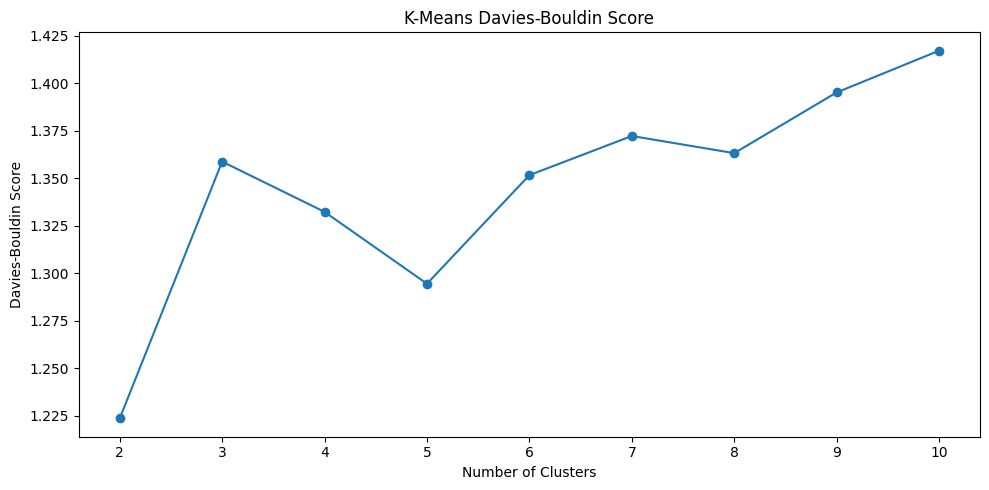

In [166]:
plt.figure(figsize=(10, 5))

plt.plot(
    kmeans_results["k"],
    kmeans_results["davies_bouldin"],
    marker="o"
)

plt.title("K-Means Davies-Bouldin Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(k_values)

plt.tight_layout()
plt.show()

In [167]:
candidate_ks = [2, 4, 5]

candidate_models = {}

for k in candidate_ks:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = model.fit_predict(X_scaled)

    candidate_models[k] = {
        "model": model,
        "labels": labels,
        "silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "davies_bouldin": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "calinski_harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        )
    }

In [168]:
for k in candidate_ks:

    labels = candidate_models[k]["labels"]

    counts = pd.Series(
        labels
    ).value_counts().sort_index()

    percentages = (
        counts / len(labels) * 100
    )

    print(f"\n========== K = {k} ==========")

    print(
        pd.DataFrame({
            "customers": counts,
            "percentage": percentages.round(2)
        })
    )


========== K = 2 ==========
   customers  percentage
0       2747      46.710
1       3134      53.290

========== K = 4 ==========
   customers  percentage
0       1434      24.380
1       1361      23.140
2       1822      30.980
3       1264      21.490

========== K = 5 ==========
   customers  percentage
0       1411      23.990
1       1726      29.350
2        945      16.070
3        621      10.560
4       1178      20.030


In [169]:
profile_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days",
    "return_order_rate",
    "return_item_rate"
]
for k in candidate_ks:

    temp = df.copy()

    temp["cluster"] = candidate_models[k]["labels"]

    profile = (
        temp
        .groupby("cluster")[profile_features]
        .median()
        .round(2)
    )

    print(f"\n========== K = {k} ==========")

    display(profile)


========== K = 2 ==========


,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,
0,313.000,1.000,321.910,186.100,98.000,19.000,1.000,0.000,0.000,0.000
1,44.000,6.000,"2,092.090",363.240,215.400,91.000,5.000,454.000,0.170,0.000



========== K = 4 ==========


,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,
0,317.000,1.000,573.930,391.710,245.000,29.000,1.000,0.000,0.000,0.000
1,26.000,11.000,"4,656.170",437.330,263.620,156.000,9.000,600.000,0.200,0.010
2,58.000,4.000,"1,047.800",226.780,121.760,57.500,4.000,374.000,0.000,0.000
3,386.000,1.000,170.260,130.460,62.000,10.000,1.000,0.000,0.000,0.000



========== K = 5 ==========


,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,
0,388.000,1.000,306.940,228.960,132.000,19.000,1.000,0.000,0.000,0.000
1,57.000,4.000,"1,004.130",226.690,121.600,56.000,4.000,374.000,0.000,0.000
2,130.000,2.000,"1,345.210",561.880,360.750,54.000,2.000,121.000,0.000,0.000
3,389.000,1.000,121.740,95.930,36.500,6.000,1.000,0.000,0.000,0.000
4,23.000,13.000,"4,976.600",393.610,231.900,172.000,10.000,625.000,0.200,0.010


In [170]:
for k in candidate_ks:

    temp = df.copy()

    temp["cluster"] = candidate_models[k]["labels"]

    profile = (
        temp
        .groupby("cluster")[profile_features]
        .median()
        .round(2)
    )

    sizes = (
        temp["cluster"]
        .value_counts()
        .sort_index()
        .rename("customers")
    )

    shares = (
        temp["cluster"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .rename("customer_share_pct")
    )

    profile = pd.concat(
        [
            sizes,
            shares,
            profile
        ],
        axis=1
    )

    print(f"\n========== K = {k} ==========")

    display(profile)


========== K = 2 ==========


,customers,customer_share_pct,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,,,
0,2747,46.710,313.000,1.000,321.910,186.100,98.000,19.000,1.000,0.000,0.000,0.000
1,3134,53.290,44.000,6.000,"2,092.090",363.240,215.400,91.000,5.000,454.000,0.170,0.000



========== K = 4 ==========


,customers,customer_share_pct,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,,,
0,1434,24.380,317.000,1.000,573.930,391.710,245.000,29.000,1.000,0.000,0.000,0.000
1,1361,23.140,26.000,11.000,"4,656.170",437.330,263.620,156.000,9.000,600.000,0.200,0.010
2,1822,30.980,58.000,4.000,"1,047.800",226.780,121.760,57.500,4.000,374.000,0.000,0.000
3,1264,21.490,386.000,1.000,170.260,130.460,62.000,10.000,1.000,0.000,0.000,0.000



========== K = 5 ==========


,customers,customer_share_pct,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,,,
0,1411,23.990,388.000,1.000,306.940,228.960,132.000,19.000,1.000,0.000,0.000,0.000
1,1726,29.350,57.000,4.000,"1,004.130",226.690,121.600,56.000,4.000,374.000,0.000,0.000
2,945,16.070,130.000,2.000,"1,345.210",561.880,360.750,54.000,2.000,121.000,0.000,0.000
3,621,10.560,389.000,1.000,121.740,95.930,36.500,6.000,1.000,0.000,0.000,0.000
4,1178,20.030,23.000,13.000,"4,976.600",393.610,231.900,172.000,10.000,625.000,0.200,0.010


In [171]:
for k in candidate_ks:

    temp = df.copy()

    temp["cluster"] = candidate_models[k]["labels"]

    comparison = pd.crosstab(
        temp["cluster"],
        temp["rfm_segment"],
        normalize="index"
    ).round(3)

    print(f"\n========== K = {k} ==========")

    display(comparison)


========== K = 2 ==========


rfm_segment,At Risk,Champions,Lost,Loyal Customers,Potential Loyalists,Regular Customers
cluster,,,,,,
0,0.062,0.002,0.493,0.048,0.176,0.219
1,0.142,0.412,0.055,0.181,0.128,0.082



========== K = 4 ==========


rfm_segment,At Risk,Champions,Lost,Loyal Customers,Potential Loyalists,Regular Customers
cluster,,,,,,
0,0.116,0.004,0.500,0.007,0.182,0.190
1,0.077,0.684,0.000,0.176,0.037,0.026
2,0.181,0.198,0.025,0.235,0.215,0.148
3,0.012,0.000,0.604,0.019,0.142,0.223



========== K = 5 ==========


rfm_segment,At Risk,Champions,Lost,Loyal Customers,Potential Loyalists,Regular Customers
cluster,,,,,,
0,0.031,0.000,0.642,0.001,0.128,0.198
1,0.189,0.188,0.016,0.241,0.226,0.140
2,0.186,0.072,0.240,0.057,0.239,0.205
3,0.008,0.000,0.586,0.032,0.140,0.233
4,0.054,0.768,0.000,0.177,0.000,0.000


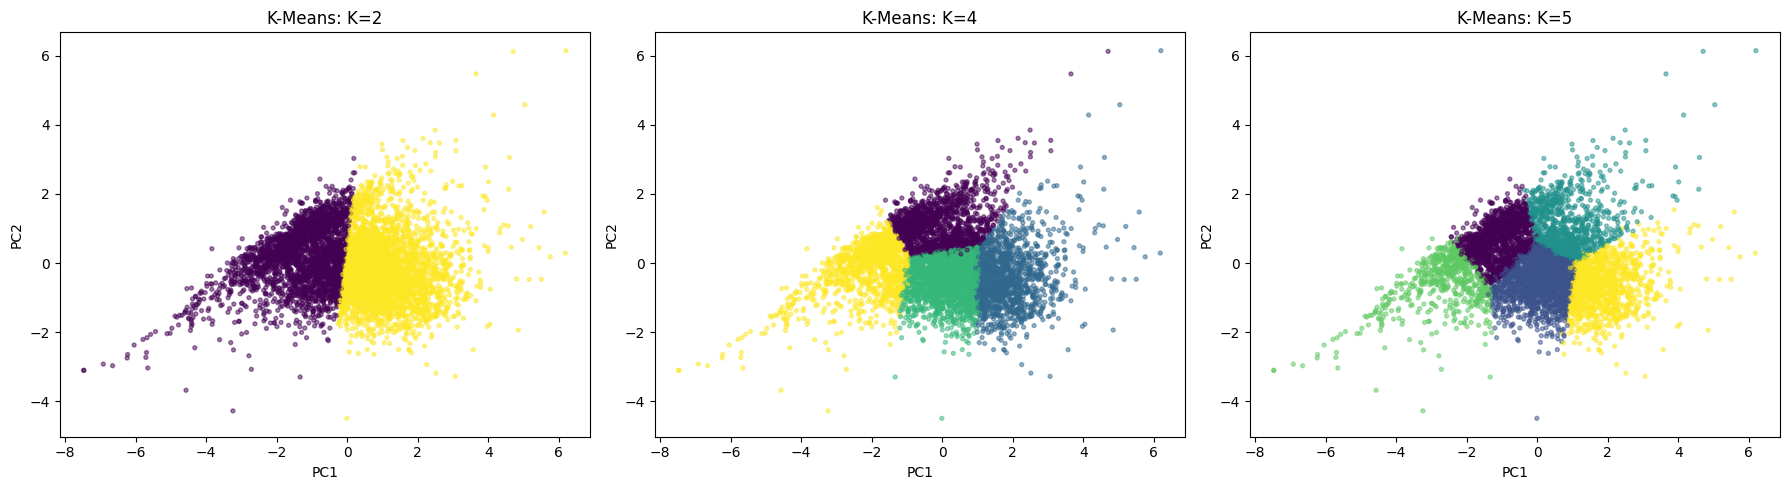

In [172]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, k in zip(axes, candidate_ks):

    labels = candidate_models[k]["labels"]

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        s=8,
        alpha=0.5
    )

    ax.set_title(
        f"K-Means: K={k}"
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## GMM

In [173]:
from sklearn.mixture import GaussianMixture

gmm_results = []

for k in range(2, 11):

    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    gmm_results.append({
        "k": k,
        "aic": model.aic(X_scaled),
        "bic": model.bic(X_scaled),
        "silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "davies_bouldin": davies_bouldin_score(
            X_scaled,
            labels
        )
    })

gmm_results = pd.DataFrame(
    gmm_results
)

gmm_results

,k,aic,bic,silhouette,davies_bouldin
0,2,130.362,858.426,0.243,1.463
1,3,"-53,924.763","-52,829.328",0.160,1.941
2,4,"-84,971.590","-83,508.784",0.113,5.018
3,5,"-74,328.253","-72,498.075",0.075,4.284
4,6,"-113,355.102","-111,157.552",0.087,4.596
5,7,"-122,702.571","-120,137.650",0.090,3.076
6,8,"-138,107.136","-135,174.844",0.085,4.006
7,9,"-141,990.823","-138,691.159",0.090,2.986
8,10,"-156,001.029","-152,333.994",0.042,3.865


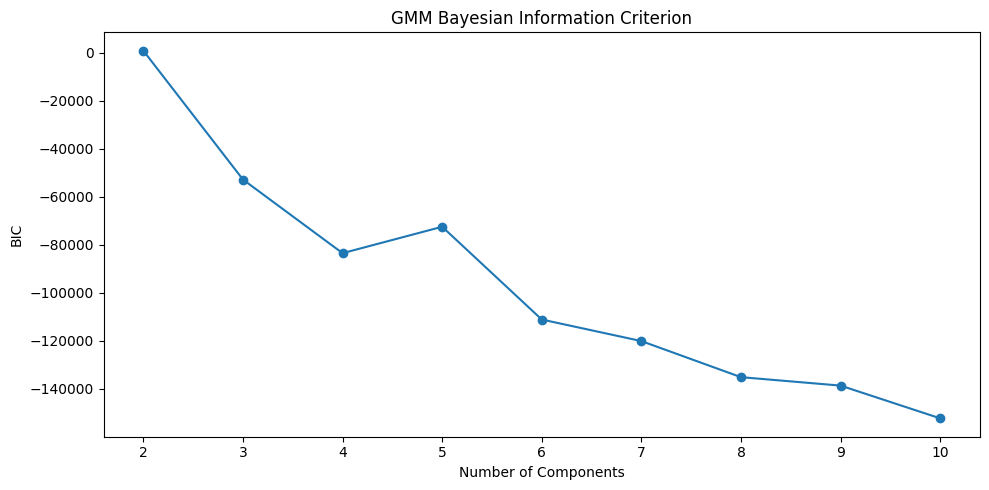

In [174]:
plt.figure(figsize=(10, 5))

plt.plot(
    gmm_results["k"],
    gmm_results["bic"],
    marker="o"
)

plt.title("GMM Bayesian Information Criterion")
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

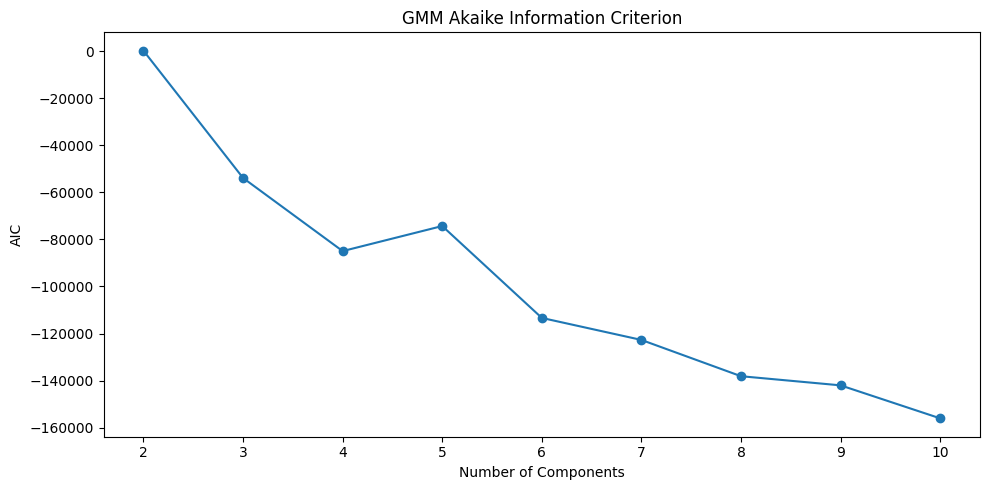

In [175]:
plt.figure(figsize=(10, 5))

plt.plot(
    gmm_results["k"],
    gmm_results["aic"],
    marker="o"
)

plt.title("GMM Akaike Information Criterion")
plt.xlabel("Number of Components")
plt.ylabel("AIC")
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

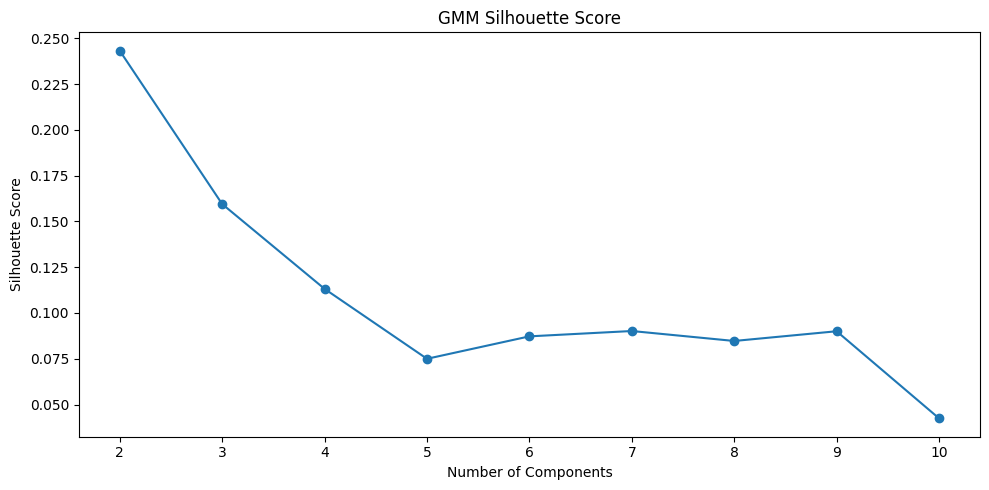

In [176]:
plt.figure(figsize=(10, 5))

plt.plot(
    gmm_results["k"],
    gmm_results["silhouette"],
    marker="o"
)

plt.title("GMM Silhouette Score")
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

## HDBSCAN

In [177]:
%pip install hdbscan

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [178]:
import hdbscan
hdbscan_results = []

for min_cluster_size in [50, 100, 200, 300]:

    model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=None,
        metric="euclidean",
        cluster_selection_method="eom"
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(
        set(labels) - {-1}
    )

    noise_pct = (
        (labels == -1).mean() * 100
    )

    if n_clusters >= 2:

        mask = labels != -1

        silhouette = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        db = davies_bouldin_score(
            X_scaled[mask],
            labels[mask]
        )

    else:

        silhouette = np.nan
        db = np.nan

    hdbscan_results.append({
        "min_cluster_size": min_cluster_size,
        "clusters": n_clusters,
        "noise_pct": round(noise_pct, 2),
        "silhouette": silhouette,
        "davies_bouldin": db
    })

hdbscan_results = pd.DataFrame(
    hdbscan_results
)

hdbscan_results

,min_cluster_size,clusters,noise_pct,silhouette,davies_bouldin
0,50,2,16.290,0.234,1.493
1,100,2,27.390,0.275,1.299
2,200,2,48.210,0.329,1.130
3,300,2,68.750,0.384,1.028


## FINAL

In [179]:
final_k = 5

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=50
)

final_labels = final_kmeans.fit_predict(
    X_scaled
)

print("Final K:", final_k)
print("Number of customers:", len(final_labels))

Final K: 5
Number of customers: 5881


In [180]:
final_silhouette = silhouette_score(
    X_scaled,
    final_labels
)

final_db = davies_bouldin_score(
    X_scaled,
    final_labels
)

final_ch = calinski_harabasz_score(
    X_scaled,
    final_labels
)

print("Final K-Means Metrics")
print("-" * 30)
print(f"Silhouette Score:       {final_silhouette:.4f}")
print(f"Davies-Bouldin Score:   {final_db:.4f}")
print(f"Calinski-Harabasz:      {final_ch:.2f}")

Final K-Means Metrics
------------------------------
Silhouette Score:       0.2189
Davies-Bouldin Score:   1.2945
Calinski-Harabasz:      2127.53


In [181]:
customer_segmented = df.copy()

customer_segmented["cluster"] = final_labels

In [182]:
customer_segmented[
    ["customer_id", "cluster"]
].head()

,customer_id,cluster
0,"12,346.000",2
1,"12,347.000",4
2,"12,348.000",2
3,"12,349.000",2
4,"12,350.000",0


In [183]:
cluster_summary = (
    customer_segmented["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

cluster_summary["customer_share_pct"] = (
    cluster_summary["customers"]
    / len(customer_segmented)
    * 100
).round(2)

cluster_summary

,customers,customer_share_pct
cluster,,
0,1411,23.990
1,1726,29.350
2,945,16.070
3,621,10.560
4,1178,20.030


In [184]:
profile_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days",
    "return_order_rate",
    "return_item_rate"
]

cluster_profiles = (
    customer_segmented
    .groupby("cluster")[profile_features]
    .median()
    .round(2)
)

cluster_profiles

,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,
0,388.000,1.000,306.940,228.960,132.000,19.000,1.000,0.000,0.000,0.000
1,57.000,4.000,"1,004.130",226.690,121.600,56.000,4.000,374.000,0.000,0.000
2,130.000,2.000,"1,345.210",561.880,360.750,54.000,2.000,121.000,0.000,0.000
3,389.000,1.000,121.740,95.930,36.500,6.000,1.000,0.000,0.000,0.000
4,23.000,13.000,"4,976.600",393.610,231.900,172.000,10.000,625.000,0.200,0.010


In [185]:
cluster_profiles["customers"] = (
    customer_segmented["cluster"]
    .value_counts()
)

cluster_profiles["customer_share_pct"] = (
    cluster_profiles["customers"]
    / len(customer_segmented)
    * 100
).round(2)

cluster_profiles

,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate,customers,customer_share_pct
cluster,,,,,,,,,,,,
0,388.000,1.000,306.940,228.960,132.000,19.000,1.000,0.000,0.000,0.000,1411,23.990
1,57.000,4.000,"1,004.130",226.690,121.600,56.000,4.000,374.000,0.000,0.000,1726,29.350
2,130.000,2.000,"1,345.210",561.880,360.750,54.000,2.000,121.000,0.000,0.000,945,16.070
3,389.000,1.000,121.740,95.930,36.500,6.000,1.000,0.000,0.000,0.000,621,10.560
4,23.000,13.000,"4,976.600",393.610,231.900,172.000,10.000,625.000,0.200,0.010,1178,20.030


In [186]:
overall_median = (
    customer_segmented[profile_features]
    .median()
)

cluster_index = (
    cluster_profiles[profile_features]
    / overall_median
).round(2)

cluster_index

,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
cluster,,,,,,,,,,
0,4.040,0.330,0.350,0.820,0.860,0.420,0.330,0.000,NaN,NaN
1,0.590,1.330,1.160,0.810,0.790,1.240,1.330,1.700,NaN,NaN
2,1.350,0.670,1.550,2.010,2.350,1.200,0.670,0.550,NaN,NaN
3,4.050,0.330,0.140,0.340,0.240,0.130,0.330,0.000,NaN,NaN
4,0.240,4.330,5.750,1.410,1.510,3.820,3.330,2.840,inf,inf


In [187]:
rfm_validation = pd.crosstab(
    customer_segmented["cluster"],
    customer_segmented["rfm_segment"],
    normalize="index"
).round(3)

rfm_validation

rfm_segment,At Risk,Champions,Lost,Loyal Customers,Potential Loyalists,Regular Customers
cluster,,,,,,
0,0.031,0.000,0.642,0.001,0.128,0.198
1,0.189,0.188,0.016,0.241,0.226,0.140
2,0.186,0.072,0.240,0.057,0.239,0.205
3,0.008,0.000,0.586,0.032,0.140,0.233
4,0.054,0.768,0.000,0.177,0.000,0.000


In [188]:
dominant_rfm = (
    rfm_validation
    .idxmax(axis=1)
    .rename("dominant_rfm_segment")
)

dominant_rfm

cluster
0               Lost
1    Loyal Customers
2               Lost
3               Lost
4          Champions
Name: dominant_rfm_segment, dtype: str

In [189]:
final_segmentation_summary = cluster_profiles.copy()

final_segmentation_summary["dominant_rfm_segment"] = (
    dominant_rfm
)

final_segmentation_summary

,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate,customers,customer_share_pct,dominant_rfm_segment
cluster,,,,,,,,,,,,,
0,388.000,1.000,306.940,228.960,132.000,19.000,1.000,0.000,0.000,0.000,1411,23.990,Lost
1,57.000,4.000,"1,004.130",226.690,121.600,56.000,4.000,374.000,0.000,0.000,1726,29.350,Loyal Customers
2,130.000,2.000,"1,345.210",561.880,360.750,54.000,2.000,121.000,0.000,0.000,945,16.070,Lost
3,389.000,1.000,121.740,95.930,36.500,6.000,1.000,0.000,0.000,0.000,621,10.560,Lost
4,23.000,13.000,"4,976.600",393.610,231.900,172.000,10.000,625.000,0.200,0.010,1178,20.030,Champions


In [190]:
cluster_names = {
    0: "Dormant Customers",
    1: "Regular Growth Customers",
    2: "High-Value Occasional Buyers",
    3: "Lost Low-Value Customers",
    4: "Champions"
}

customer_segmented["customer_segment"] = (
    customer_segmented["cluster"]
    .map(cluster_names)
)

customer_segmented[
    [
        "customer_id",
        "cluster",
        "customer_segment"
    ]
].head(10)

,customer_id,cluster,customer_segment
0,"12,346.000",2,High-Value Occasional Buyers
1,"12,347.000",4,Champions
2,"12,348.000",2,High-Value Occasional Buyers
3,"12,349.000",2,High-Value Occasional Buyers
4,"12,350.000",0,Dormant Customers
5,"12,351.000",0,Dormant Customers
6,"12,352.000",1,Regular Growth Customers
7,"12,353.000",0,Dormant Customers
8,"12,354.000",2,High-Value Occasional Buyers
9,"12,355.000",2,High-Value Occasional Buyers


In [191]:
business_summary = (
    customer_segmented
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        median_recency=("recency", "median"),
        median_frequency=("frequency", "median"),
        median_monetary=("monetary", "median"),
        median_aov=("avg_order_value", "median"),
        median_products=("unique_products", "median"),
        median_return_rate=("return_order_rate", "median")
    )
    .round(2)
)

business_summary["customer_share_pct"] = (
    business_summary["customers"]
    / business_summary["customers"].sum()
    * 100
).round(2)

business_summary

,customers,median_recency,median_frequency,median_monetary,median_aov,median_products,median_return_rate,customer_share_pct
customer_segment,,,,,,,,
Champions,1178,23.000,13.000,"4,976.600",393.610,172.000,0.200,20.030
Dormant Customers,1411,388.000,1.000,306.940,228.960,19.000,0.000,23.990
High-Value Occasional Buyers,945,130.000,2.000,"1,345.210",561.880,54.000,0.000,16.070
Lost Low-Value Customers,621,389.000,1.000,121.740,95.930,6.000,0.000,10.560
Regular Growth Customers,1726,57.000,4.000,"1,004.130",226.690,56.000,0.000,29.350


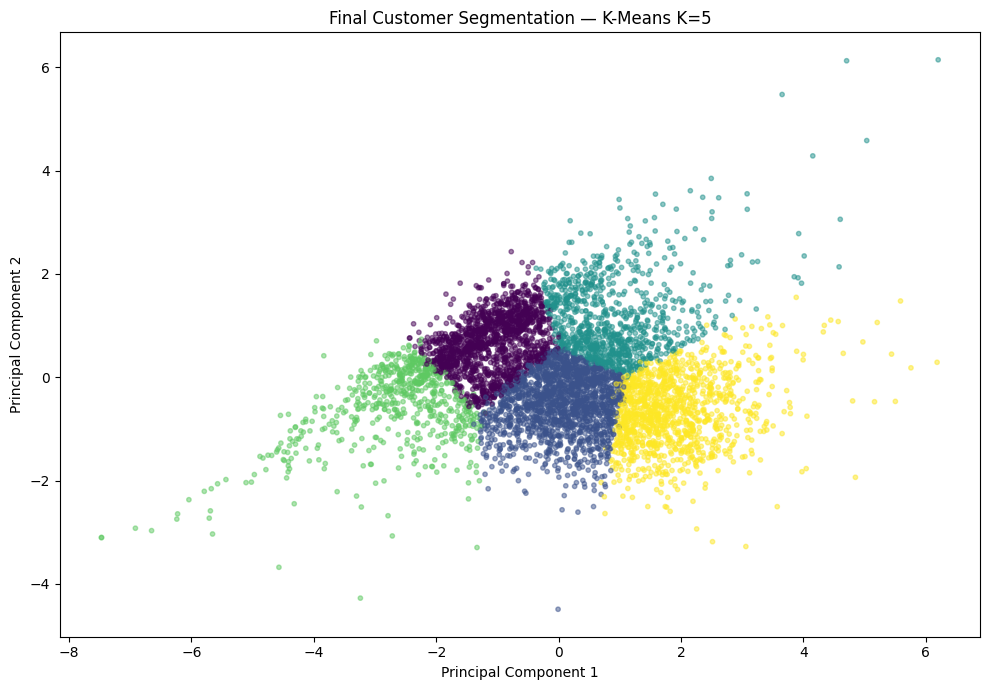

In [192]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels,
    s=10,
    alpha=0.5
)

plt.title("Final Customer Segmentation — K-Means K=5")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [193]:
output_path = "D:/clv/data/processed/customer_segments.csv"

customer_segmented.to_csv(
    output_path,
    index=False
)

print(
    f"Saved segmented customer data to: {output_path}"
)
import joblib

joblib.dump(
    final_kmeans,
    "D:/clv/models/customer_kmeans.pkl"
)

joblib.dump(
    scaler,
    "D:/clv/models/customer_scaler.pkl"
)

print("K-Means model and scaler saved.")

Saved segmented customer data to: D:/clv/data/processed/customer_segments.csv
K-Means model and scaler saved.




## Customer Segmentation Model

This notebook developed the unsupervised learning layer of the Customer Intelligence Analytics Platform.

The customer-level behavioral features were prepared for clustering through skewness analysis, selective log transformation, return-behavior treatment, feature selection, and robust scaling. PCA was then used as a diagnostic tool to understand the structure of the customer feature space.

Multiple clustering approaches were evaluated:

- **K-Means:** tested across 2–10 clusters using Inertia, Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.
- **Gaussian Mixture Model:** evaluated using AIC, BIC, Silhouette Score, and Davies-Bouldin Index.
- **HDBSCAN:** evaluated using cluster separation and the proportion of customers classified as noise.

Although K=2 achieved the strongest statistical separation under K-Means, it produced an overly broad two-group segmentation. K=5 provided a better balance between statistical quality, cluster size, behavioral differentiation, and business interpretability.

### Final Segmentation

The selected **K-Means K=5** model identified five customer personas:

1. **High-Value Occasional Buyers**
2. **Dormant Customers**
3. **Champions**
4. **Lost Low-Value Customers**
5. **Regular Growth Customers**

RFM segmentation was used as an external validation layer rather than as an input to the clustering model.

The final customer-level segmentation has been saved as:

`data/processed/customer_segments.csv`

The trained K-Means model and scaler have also been persisted for reproducibility.

### Key Outcome

The result is not simply a set of machine-learning clusters. It is a behavioral customer segmentation layer that can be used to understand **who the customers are, how they behave, how valuable they are, and where different customer groups represent retention, growth, or reactivation opportunities**.

**Next Step:** Use the final customer segments for Customer Intelligence & Business Analytics and build the corresponding Power BI analytical layer.